In [1]:
import sys  
sys.path.insert(1, '/home/phong/bin')
from plotting_header import *
import glob
import ROOT
import time
from IPython.display import display

import numpy as np
from scipy.stats import johnsonsu,norm
from iminuit import Minuit
from iminuit.cost import ExtendedUnbinnedNLL,ExtendedBinnedNLL
import matplotlib.pyplot as plt
from scipy.optimize import minimize,root_scalar
from jacobi import propagate
%matplotlib inline

import matplotlib.font_manager as font_manager
import matplotlib
font = {'family' : 'Liberation Serif',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.use('TkAgg')  # Or 'TkAgg', etc., before any plotting
import numpy as np
from scipy.stats import johnsonsu
from scipy.optimize import minimize_scalar, root_scalar
%matplotlib inline


Welcome to JupyROOT 6.26/14


In [2]:
nudat3 = np.load("heavy/nudat3/nudat3datanpynew.npy",allow_pickle='TRUE')

5537


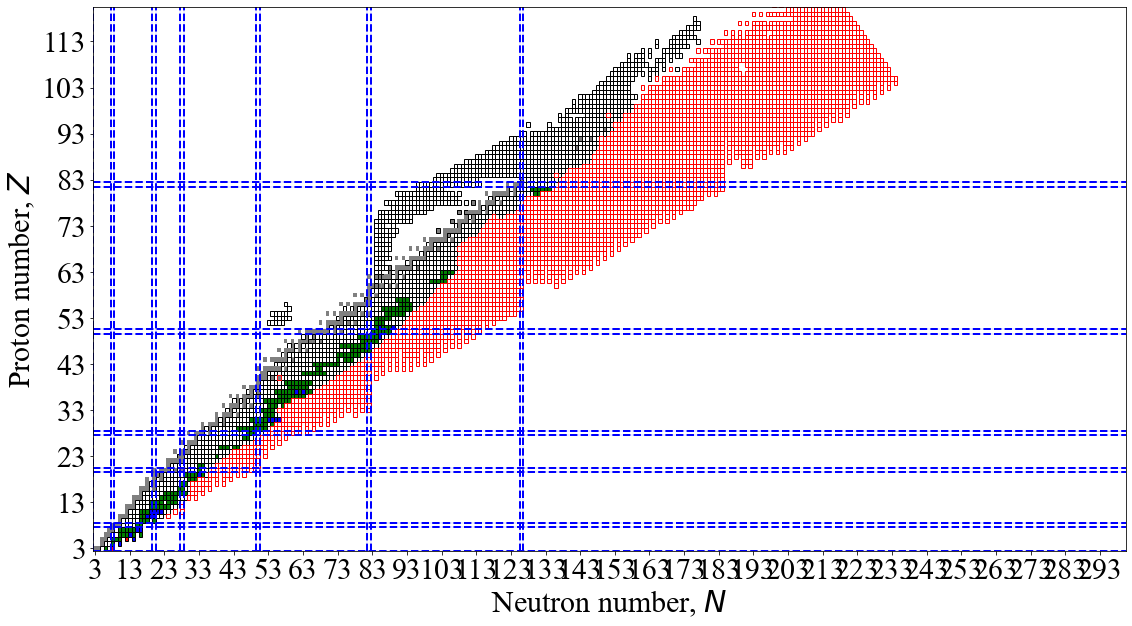

In [3]:
import matplotlib
font = {'family' : 'Times New Roman',
        'weight' : 'normal',
        'size'   : 30}
matplotlib.rc('font', **font)


Zlim = [2.5,120.5]
Nlim = [2.5,300.5]
NZstep = [10,10]
fig,axis = plt.subplots()
fig.set_size_inches(18.5,10)
fig.subplots_adjust(hspace=0,wspace=0)

year_to_s = 31556926.
ftoSeconds = {"Yy":year_to_s*1e24,"Zy":year_to_s*1e21,"Ey":year_to_s*1e18,"Py":year_to_s*1e15,"Ty":year_to_s*1e12,
     "Gy":year_to_s*1e9,"My":year_to_s*1e6,"ky":year_to_s*1e3,
     "y":year_to_s,"d":24*3600,"h":3600.,"m":60.,"s":1.,
    "ms":1e-3,"us":1e-3,"ns":1e-9,"ps":1e-12,"fs":1e-15,"as":1e-18,"zs":1e-21,"ys":1e-24}

plot_base(axis,Nlim,Zlim,NZstep)
k = 0

decaydatanudat3 = []
nudatdata = {}
for idx,i in enumerate(nudat3):
    namesimplified = "%s%d" % (getnamebyz(i["z"]),i["n"]+i["z"])
    namesimplified2 = "%d%s" % (i["n"]+i["z"],getnamebyz(i["z"]).capitalize())
    if ("levels" in i): 
        if ("halflife" in i['levels'][0]):
            if (i['levels'][0]['halflife']['value']=='STABLE'):
                axis.add_patch(drawbox(i["n"],i["z"],fcolor='gray',ecolor='None'))
            if (i['levels'][0]['halflife']['value']!='STABLE' and (i['levels'][0]['halflife']['uncertainty']['type']=='asymmetric' or i['levels'][0]['halflife']['uncertainty']['type']=='symmetric')):
                t12 = float(i['levels'][0]['halflife']['value'])
                t12errUp = 0.
                t12errLow = 0.
                if (i['levels'][0]['halflife']['uncertainty']['type']=='symmetric'):
                    t12errUp = float(i['levels'][0]['halflife']['uncertainty']['value'])
                    t12errLow = float(i['levels'][0]['halflife']['uncertainty']['value'])
                if (i['levels'][0]['halflife']['uncertainty']['type']=='asymmetric'):
                    t12errLow = i['levels'][0]['halflife']['uncertainty']['lowerLimit']
                    t12errUp = i['levels'][0]['halflife']['uncertainty']['upperLimit']
                if (i['levels'][0]['halflife']['unit']!='keV' and 
                    i['levels'][0]['halflife']['unit']!='MeV' and 
                    i['levels'][0]['halflife']['unit']!='eV'):
                    #Pn values
                    pn = [0.,0.,0.]
                    p2n = [0.,0.,0.]
                    p3n = [0.,0.,0.]
                    adecay = [0.,0.,0.]
                    bdecay = [0.,0.,0.]
                    for j in i['levels'][0]["decayModes"]['observed']:
                        if (j['mode']=="B-"):
                            bdecay[0] = j['value']
                            if (j['uncertainty']['type']=='symmetric'):
                                bdecay[1] = j['uncertainty']["value"]
                                bdecay[2] = j['uncertainty']["value"]
                            elif (j['uncertainty']['type']=='asymmetric'):
                                bdecay[1] = j['uncertainty']["lowerLimit"]
                                bdecay[2] = j['uncertainty']["upperLimit"]
                        if (j['mode']=="A"):
                            adecay[0] = j['value']
                            if (j['uncertainty']['type']=='symmetric'):
                                adecay[1] = j['uncertainty']["value"]
                                adecay[2] = j['uncertainty']["value"]
                            elif (j['uncertainty']['type']=='asymmetric'):
                                adecay[1] = j['uncertainty']["lowerLimit"]
                                adecay[2] = j['uncertainty']["upperLimit"]                                
                        if (j['mode']=="B-N" and (j['uncertainty']['type']=='asymmetric' or j['uncertainty']['type']=='symmetric')):
                            if (j['uncertainty']['type']=='symmetric'):
                                pn[0] = j['value']
                                pn[1] = j['uncertainty']["value"]
                                pn[2] = j['uncertainty']["value"]
                            elif (j['uncertainty']['type']=='asymmetric'):
                                pn[0] = j['value']
                                pn[1] = j['uncertainty']["lowerLimit"]
                                pn[2] = j['uncertainty']["upperLimit"]
                            axis.add_patch(drawbox(i["n"],i["z"],fcolor='g',ecolor='None'))
                        if (j['mode']=="B-2N" and (j['uncertainty']['type']=='asymmetric' or j['uncertainty']['type']=='symmetric')):
                            if (j['uncertainty']['type']=='symmetric'):
                                p2n[0] = j['value']
                                p2n[1] = j['uncertainty']["value"]
                                p2n[2] = j['uncertainty']["value"]
                            elif (j['uncertainty']['type']=='asymmetric'):
                                p2n[0] = j['value']
                                p2n[1] = j['uncertainty']["lowerLimit"]
                                p2n[2] = j['uncertainty']["upperLimit"]
                            axis.add_patch(drawbox(i["n"],i["z"],fcolor='b',ecolor='None'))
                        if (j['mode']=="B-3N" and (j['uncertainty']['type']=='asymmetric' or j['uncertainty']['type']=='symmetric')):
                            if (j['uncertainty']['type']=='symmetric'):
                                p3n[0] = j['value']
                                p3n[1] = j['uncertainty']["value"]
                                p3n[2] = j['uncertainty']["value"]
                            elif (j['uncertainty']['type']=='asymmetric'):
                                p3n[0] = j['value']
                                p3n[1] = j['uncertainty']["lowerLimit"]
                                p3n[2] = j['uncertainty']["upperLimit"]
                            axis.add_patch(drawbox(i["n"],i["z"],fcolor='r',ecolor='None'))
                    unitmult = ftoSeconds[i['levels'][0]['halflife']['unit']]
                    t12sec = t12*unitmult
                    if (t12sec>1e15):
                        axis.add_patch(drawbox(i["n"],i["z"],fcolor='gray',ecolor='None'))
                    
                    if (adecay[0]>0. or bdecay[0]>0.):
                        axis.add_patch(drawbox(i["n"],i["z"],fcolor='None',ecolor='k'))
                        decaydatanudat3.append({"source":"nubase","nuc":namesimplified,"nuclide":namesimplified2,"Z":i["z"],"N":i["n"],"A":i["n"]+i["z"],"ZA":i["z"]*1000+i["n"]+i["z"],
                                           "t12":t12sec,"t12l":t12errLow*unitmult,"t12u":t12errUp*unitmult,
                                                "b_br":bdecay[0],"b_brl":bdecay[1],"b_bru":bdecay[2],
                                                "a_br":adecay[0],"a_brl":adecay[1],"a_bru":adecay[2],
                                                "pn":pn[0],"pnl":pn[1],"pnu":pn[2],
                                                "p2n":p2n[0],"p2nl":p2n[1],"p2nu":p2n[2],
                                                "p3n":p3n[0],"p3nl":p3n[1],"p3nu":p3n[2],
                                                "t12theo":-9999.,"pntheo":-9999.,"p2ntheo":-9999.,"p3ntheo":-9999.})
                        nudatdata[namesimplified] = 1

def get_theories_bdecay(sheetname = "FRDM_QRPA-HF",nmult = 10,div = 1.):
    df_theo = pd.read_excel('heavy/models/theory_data_230529.xlsx',sheet_name=sheetname, engine='openpyxl')
    data_theo = []
    cnt = 0
    for index, row in df_theo.iterrows():
        if (nmult==10):
            data_theo.append({'Z': int(row['Z']), 'N': int(row['N']), 'A': int(row['A']), 
                              'P0n': float(row['P0n'])/div, 'P1n': float(row['P1n'])/div, 'P2n': float(row['P2n'])/div, 
                              'P3n': float(row['P3n'])/div, 'P4n': float(row['P4n'])/div, 'P5n': float(row['P5n'])/div, 
                              'P6n': float(row['P6n'])/div, 'P7n': float(row['P7n'])/div, 'P8n': float(row['P8n'])/div, 
                              'P9n': float(row['P9n'])/div, 'P10n': float(row['P10n'])/div,'T12':float(row['T12(s)'])})
        if (nmult==5):
            data_theo.append({'Z': int(row['Z']), 'N': int(row['N']), 'A': int(row['A']), 
                              'P0n': float(row['P0n'])/div, 'P1n': float(row['P1n'])/div, 'P2n': float(row['P2n'])/div, 
                              'P3n': float(row['P3n'])/div, 'P4n': float(row['P4n'])/div, 'P5n': float(row['P5n'])/div, 
                              'T12':float(row['T12(s)'])})
        if (nmult==3):
            data_theo.append({'Z': int(row['Z']), 'N': int(row['N']), 'A': int(row['A']), 
                              'P0n': float(row['P0n'])/div, 'P1n': float(row['P1n'])/div, 'P2n': float(row['P2n'])/div, 
                              'P3n': float(row['P3n'])/div, 'T12':float(row['T12(s)'])})
        cnt+=1
#         if (cnt<3):
#             print(float(row['P0n']))
    return data_theo
data_frdm = np.load("heavy/models/data_frdm12.npy",allow_pickle='TRUE')
data_frdm_bound_vsnuc = {}
for i in data_frdm:
    namesimplified = "%s%d" % (getnamebyz(i["Z"]),i["N"]+i["Z"])
    if (i["isbound"]):
        data_frdm_bound_vsnuc[namesimplified] = 1

bdat_FRDM_QRPA_HF = get_theories_bdecay("FRDM_QRPA-HF",10)
for i in bdat_FRDM_QRPA_HF:
    namesimplified = "%s%d" % (getnamebyz(i["Z"]),i["N"]+i["Z"])
    namesimplified2 = "%d%s" % (i["N"]+i["Z"],getnamebyz(i["Z"]).capitalize())
    if (not (namesimplified in data_frdm_bound_vsnuc)):
        continue
    if (not (namesimplified in nudatdata)):
        axis.add_patch(drawbox(i["N"],i["Z"],fcolor='None',ecolor='r'))
        decaydatanudat3.append({"source":"frdm","nuc":namesimplified,"nuclide":namesimplified2,"Z":i["Z"],"N":i["N"],"A":i["N"]+i["Z"],"ZA":i["Z"]*1000+i["N"]+i["Z"],
                                           "t12":i["T12"],"t12l":i["T12"]-i["T12"]/100,"t12u":i["T12"]*100-i["T12"],
                                                "b_br":100.,"b_brl":0.,"b_bru":0.,
                                                "a_br":0.,"a_brl":0.,"a_bru":0.,
                                                "pn":i["P1n"],"pnl":i["P1n"]-i["P1n"]/10.,"pnu":(i["P1n"]*10.-i["P1n"]) if ((i["P1n"]*10.-i["P1n"])<100) else 100-i["P1n"],
                                                "p2n":i["P2n"],"p2nl":i["P2n"]-i["P2n"]/10.,"p2nu":(i["P2n"]*10.-i["P2n"]) if ((i["P2n"]*10.-i["P2n"])<100) else 100-i["P2n"],
                                                "p3n":i["P3n"],"p3nl":i["P3n"]-i["P3n"]/10.,"p3nu":(i["P3n"]*10.-i["P3n"]) if ((i["P3n"]*10.-i["P3n"])<100) else 100-i["P3n"],
                               "t12theo":i["T12"],"pntheo":i["P1n"],"p2ntheo":i["P2n"],"p3ntheo":i["P3n"]})
    else:
        entrynudat = next((item for item in decaydatanudat3 if (item["nuc"] == namesimplified)), None)
        if (entrynudat==None):
            print("something wrong")
        entrynudat["source"]="mix"
        entrynudat["t12theo"]=i["T12"]
        entrynudat["pntheo"]=i["P1n"]
        entrynudat["p2ntheo"]=i["P2n"]
        entrynudat["p3ntheo"]=i["P3n"]

df = pd.DataFrame(decaydatanudat3)
print(len(decaydatanudat3))
df.to_csv("parms/decaydatanudat3.csv", index=False)

magic_num = [2, 8, 20, 28, 50, 82, 126]
for i in magic_num:
    axis.axhline(y=i+0.5,color='b',linestyle='--',linewidth=2)
    axis.axhline(y=i-0.5,color='b',linestyle='--',linewidth=2)
    axis.axvline(x=i+0.5,color='b',linestyle='--',linewidth=2)
    axis.axvline(x=i-0.5,color='b',linestyle='--',linewidth=2)


In [4]:
dz10 = np.load("heavy/models/data_dz10.npy",allow_pickle='TRUE')
print(dz10[0])

{'ZA': 20029, 'N': 9, 'Z': 20, 'A': 29, 'EL': 'ca', 'Ebind': 122.253, 'mass': 96.16828381999998, 'S1n': 0.0, 'S2n': 0.0, 'S1p': 0.0, 'S2p': -14.411, 'Qb': -999999, 'Qbn': -999999, 'isbound': False}


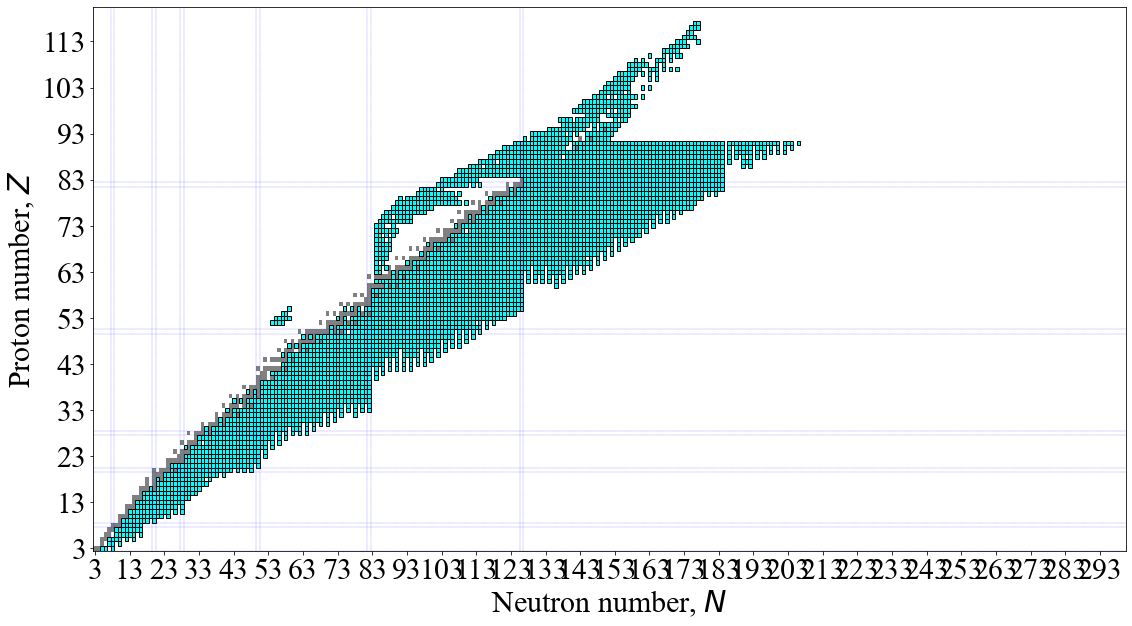

In [5]:
##add Qvalues and Sn
data_masstable = np.load("heavy/ame/mass_1.mas20.npy",allow_pickle='TRUE')
data_Qbn = np.load("heavy/ame/rct1.mas20.npy",allow_pickle='TRUE')
data_Sn = np.load("heavy/ame/rct2_1.mas20.npy",allow_pickle='TRUE')
decaydatanudat3_Q = []
ame = np.load("heavy/ame/all_ame20.npy",allow_pickle='TRUE')

fig,axis = plt.subplots()
fig.set_size_inches(18.5,10)
fig.subplots_adjust(hspace=0,wspace=0)

plot_base(axis,Nlim,Zlim,NZstep)
k = 0

for idx, i in enumerate(ame):
    if (i["N"] == 1 and i["Z"] == 0):
        mass_neutron = i["M"]
        dmass_neutron = i["DM"]
dz10 = np.load("heavy/models/data_dz10.npy",allow_pickle='TRUE')


txt = ""
for idx,i in enumerate(nudat3):
    if ("levels" in i): 
        if ("halflife" in i['levels'][0]):
            if (i['levels'][0]['halflife']['value']=='STABLE'):
                axis.add_patch(drawbox(i["n"],i["z"],fcolor='gray',ecolor='None'))
                z = i["z"]
                n = i["n"]
                txt+=f"{z}\t{n}\n"
            if (i['levels'][0]['halflife']['value']!='STABLE'):
                t12 = float(i['levels'][0]['halflife']['value'])
                if (i['levels'][0]['halflife']['unit']!='keV' and 
                    i['levels'][0]['halflife']['unit']!='MeV' and 
                    i['levels'][0]['halflife']['unit']!='eV'):
                    unitmult = ftoSeconds[i['levels'][0]['halflife']['unit']]
                    if (t12*unitmult>1e15):
                        axis.add_patch(drawbox(i["n"],i["z"],fcolor='gray',ecolor='None'))
                        z = i["z"]
                        n = i["n"]
                        txt+=f"{z}\t{n}\n"
with open("stable.csv","w") as f:
    f.write(txt)
for idx,i in enumerate(decaydatanudat3):
    ii = copy.deepcopy(i)
    a = i["A"]
    z = i["Z"]
    n = i["N"]
    t12 = i["t12"]
    
    
    errflag = False
    Qb_entry = next((item for item in data_masstable if (item["A"] == a and item["Z"] == z)), None)
    if (Qb_entry==None):
        errflag = True
#         print("Error Qb_entry",i["nuc"])
    
    #Sn daugter
    Sn_daugter_entry = next((item for item in data_Sn if (item["A"] == a and item["Z"] == z+1)), None)
    if (Sn_daugter_entry==None):
        errflag = True
#         print("Error Sn_daugter_entry",i["nuc"])
    
    #S2n daugter
    S2n_daugter_entry = next((item for item in data_Qbn if (item["A"] == a and item["Z"] == z+1)), None)
    if (S2n_daugter_entry==None):
        errflag = True
#         print("Error Sn_daugter_entry",i["nuc"])
    #Qbn, S2n
    Qbn_entry = next((item for item in data_Qbn if (item["A"] == a and item["Z"] == z)), None)
    if (Qbn_entry==None):
        errflag = True
#         print("Error Qbn_entry",i["nuc"])
    if (errflag):
        entrydz10 = next((item for item in dz10 if (item["Z"] == z and item["N"] == n)), None)
        if (entrydz10==None):
            continue
        else:
            if entrydz10["Qb"]<0:
                continue
            M = entrydz10["mass"]*1000.
            DM = 1000.
            Qb = entrydz10["Qb"]*1000.
            D_Qb = 1000.
            S2n = entrydz10["S2n"]*1000.
            D_S2n = 1000.
            Qbn = entrydz10["Qbn"]*1000.
            D_Qbn = 1000.
            S1n_daughter = entrydz10["S1n"]*1000.
            D_S1n_daughter = 1000.
            S2n_daughter = entrydz10["S2n"]*1000.
            D_S2n_daughter = 1000.
            Qb2n = Qb-S2n_daughter
            D_Qb2n = math.sqrt(D_Qb*D_Qb+D_S2n_daughter*D_S2n_daughter)
    else:
        M = Qb_entry["M"]
        DM = Qb_entry["DM"]
        Qb = Qb_entry["Qb"]
#         print(Qb)
        D_Qb = Qb_entry["DQb"]
        S2n = Qbn_entry["S2n"]
        D_S2n = Qbn_entry["D_S2n"]
        Qbn = Qbn_entry["Qbn"]
        D_Qbn = Qbn_entry["D_Qbn"]
        S1n_daughter = Sn_daugter_entry["Sn"]
        D_S1n_daughter = Sn_daugter_entry["D_Sn"]
        S2n_daughter = S2n_daugter_entry["S2n"]
        D_S2n_daughter = S2n_daugter_entry["D_S2n"]
        Qb2n = Qb-S2n_daughter
        D_Qb2n = math.sqrt(D_Qb*D_Qb+D_S2n_daughter*D_S2n_daughter)
    if (i["t12"]<1e10):
        ii["M"] = M
        ii["DM"] = DM
        ii["Qb"] = Qb
        ii["D_Qb"] = D_Qb
        ii["S2n"] = S2n
        ii["D_S2n"] = D_S2n
        ii["Qbn"] = Qbn
        ii["D_Qbn"] = D_Qbn
        ii["S1n_daughter"] = S1n_daughter
        ii["D_S1n_daughter"] = D_S1n_daughter
        ii["Qb2n"] = Qb2n
        ii["D_Qb2n"] = D_Qb2n
        ii["S2n_daughter"] = S2n_daughter
        ii["D_S2n_daughter"] = D_S2n_daughter
        decaydatanudat3_Q.append(ii)
        axis.add_patch(drawbox(ii["N"],ii["Z"],fcolor='cyan',ecolor='k'))
dff = pd.DataFrame(decaydatanudat3)

In [6]:
group_df_sorted = dff.sort_values(by=['ZA'], ascending=[True])
txt = ""
for idx, row in group_df_sorted.iterrows():

    z = row["Z"]
    n = row["N"]
    t12 = row["t12"]
    txt+=f"{z}\t{n}\t{t12}\n"
with open("FRDM-QRPA12-halflife.txt","w") as f:
    f.write(txt)
# txt+=f"{z}\t{n}\t{t12}\n"

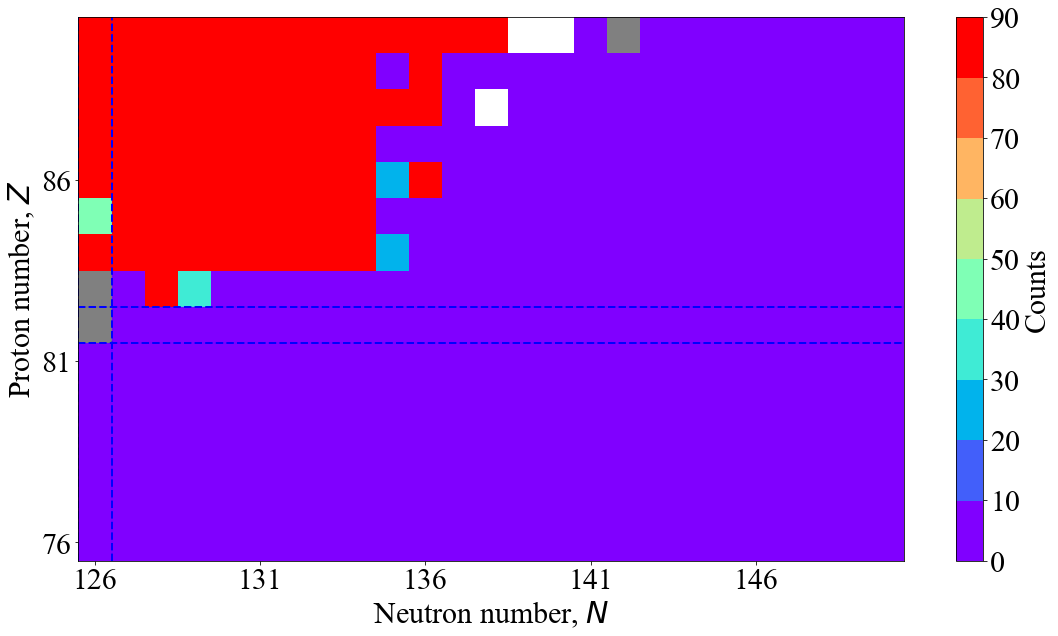

In [7]:
fig,axis = plt.subplots()
fig.set_size_inches(18.5,10)
fig.subplots_adjust(hspace=0,wspace=0)

Zlim = [75.5,90.5]
Nlim = [125.5,150.5]
NZstep = [5,5]

plot_base(axis,Nlim,Zlim,NZstep)
k = 0

for idx,i in enumerate(nudat3):
    if ("levels" in i): 
        if ("halflife" in i['levels'][0]):
            if (i['levels'][0]['halflife']['value']=='STABLE'):
                axis.add_patch(drawbox(i["n"],i["z"],fcolor='gray',ecolor='None'))
            if (i['levels'][0]['halflife']['value']!='STABLE'):
                t12 = float(i['levels'][0]['halflife']['value'])
                if (i['levels'][0]['halflife']['unit']!='keV' and 
                    i['levels'][0]['halflife']['unit']!='MeV' and 
                    i['levels'][0]['halflife']['unit']!='eV'):
                    unitmult = ftoSeconds[i['levels'][0]['halflife']['unit']]
                    if (t12*unitmult>1e15):
                        axis.add_patch(drawbox(i["n"],i["z"],fcolor='gray',ecolor='None'))

cmax = 100
cmin = 0
bounds = np.arange(cmin,cmax,10)
cmap,sm,norm = getcmap(bounds,"rainbow")
cbar = fig.colorbar(sm, ticks=bounds, label="Counts", aspect=20, orientation='vertical', ax=axis)
for idx,i in enumerate(decaydatanudat3_Q):
    axis.add_patch(drawbox(i["N"],i["Z"],fcolor=cmap(norm(i["a_br"])),ecolor='None'))
magic_num = [2, 8, 20, 28, 50, 82, 126]
for i in magic_num:
    axis.axhline(y=i+0.5,color='b',linestyle='--',linewidth=2)
    axis.axhline(y=i-0.5,color='b',linestyle='--',linewidth=2)
    axis.axvline(x=i+0.5,color='b',linestyle='--',linewidth=2)
    axis.axvline(x=i-0.5,color='b',linestyle='--',linewidth=2)

    

3853


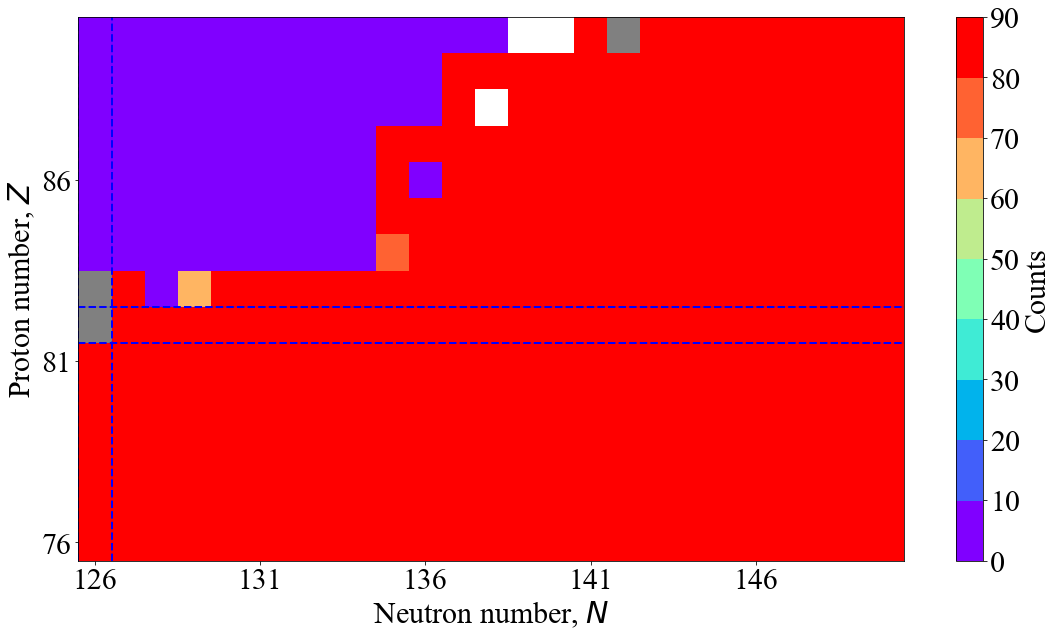

In [8]:
fig,axis = plt.subplots()
fig.set_size_inches(18.5,10)
fig.subplots_adjust(hspace=0,wspace=0)

Zlim = [75.5,90.5]
Nlim = [125.5,150.5]
NZstep = [5,5]

plot_base(axis,Nlim,Zlim,NZstep)
k = 0

for idx,i in enumerate(nudat3):
    if ("levels" in i): 
        if ("halflife" in i['levels'][0]):
            if (i['levels'][0]['halflife']['value']=='STABLE'):
                axis.add_patch(drawbox(i["n"],i["z"],fcolor='gray',ecolor='None'))
            if (i['levels'][0]['halflife']['value']!='STABLE'):
                t12 = float(i['levels'][0]['halflife']['value'])
                if (i['levels'][0]['halflife']['unit']!='keV' and 
                    i['levels'][0]['halflife']['unit']!='MeV' and 
                    i['levels'][0]['halflife']['unit']!='eV'):
                    unitmult = ftoSeconds[i['levels'][0]['halflife']['unit']]
                    if (t12*unitmult>1e15):
                        axis.add_patch(drawbox(i["n"],i["z"],fcolor='gray',ecolor='None'))

cmax = 100
cmin = 0
bounds = np.arange(cmin,cmax,10)
cmap,sm,norm = getcmap(bounds,"rainbow")
cbar = fig.colorbar(sm, ticks=bounds, label="Counts", aspect=20, orientation='vertical', ax=axis)
for idx,i in enumerate(decaydatanudat3_Q):
    axis.add_patch(drawbox(i["N"],i["Z"],fcolor=cmap(norm(i["b_br"])),ecolor='None'))
magic_num = [2, 8, 20, 28, 50, 82, 126]
for i in magic_num:
    axis.axhline(y=i+0.5,color='b',linestyle='--',linewidth=2)
    axis.axhline(y=i-0.5,color='b',linestyle='--',linewidth=2)
    axis.axvline(x=i+0.5,color='b',linestyle='--',linewidth=2)
    axis.axvline(x=i-0.5,color='b',linestyle='--',linewidth=2)
df = pd.DataFrame(decaydatanudat3_Q)
print(len(decaydatanudat3_Q))
df.to_csv("parms/decaydatanudat3_Q.csv", index=False)

In [9]:
from calculate_eff import *

In [17]:
df = pd.read_csv ("parms/decaydatanudat3_Q.csv")
cal_results = []

Zlim = [73.5,92.5]
Nlim = [123.5,152.5]

df_filtered = df[(df["Z"] > Zlim[0]) & (df["Z"] < Zlim[1]) & (df["N"] > Nlim[0]) & (df["N"] < Nlim[1])]
for index, row in df_filtered.iterrows():
    e_mean=0.;eff_mean=0.668;e_low=0.;eff_low=0.668-0.02;e_hi=0.;eff_hi=0.668+0.02;e_mean_fit=0.;e_sigma=0.
    if (row["Qb"]>0):
        if (row["Qbn"]>0):
            e_mean,eff_mean,e_low,eff_low,e_hi,eff_hi,e_mean_fit,e_sigma = cal_all(row["Qb"]/1000.,row["S1n_daughter"]/1000.,row["D_Qb"]/1000.,row["D_S1n_daughter"]/1000.,1.,row["Z"])
    e_mean2=0.;eff_mean2=0.668;e_low2=0.;eff_low2=0.668-0.02;e_hi2=0.;eff_hi2=0.668+0.02;e_mean_fit2=0.;e_sigma2=0.
    if (row["Qb"]>0):
        if (row["Qb2n"]>0):
            e_mean2,eff_mean2,e_low2,eff_low2,e_hi2,eff_hi2,e_mean_fit2,e_sigma2 = cal_all(row["Qb"]/1000.,row["S2n_daughter"]/1000.,row["D_Qb"]/1000.,row["D_S2n_daughter"]/1000.,0.5,row["Z"])
    effmean_norm = 66.8 / 100.
    deffmean_norm  = 2. / 100.
    if (e_mean<=0):
        eff_mean = effmean_norm
        eff_low = effmean_norm + deffmean_norm
        eff_hi = effmean_norm - deffmean_norm
    eff_m = eff_mean - eff_hi
    eff_p = eff_low - eff_mean
    if (e_mean2<=0):
        eff_mean2 = effmean_norm
        eff_low2 = effmean_norm + deffmean_norm
        eff_hi2 = effmean_norm - deffmean_norm
    eff_m2 = eff_mean2 - eff_hi2
    eff_p2 = eff_low2 - eff_mean2
    
    if (eff_m<0):
        print(row['nuclide'],"eff_m <0, ",e_mean)
        eff_mean = effmean_norm
        eff_m = deffmean_norm
        eff_p = deffmean_norm
        
    if (eff_p<0):
        print(row['nuclide'],"eff_p <0, ",e_mean)   
        eff_mean = effmean_norm
        eff_m = deffmean_norm
        eff_p = deffmean_norm      

    if (eff_m2<0):
        print(row['nuclide'],"eff_m2 <0, ",e_mean2)
        eff_mean2 = effmean_norm
        eff_m2 = deffmean_norm
        eff_p2 = deffmean_norm
        
    if (eff_p2<0):
        print(row['nuclide'],"eff_p2 <0, ",e_mean2)
        eff_mean2 = effmean_norm
        eff_m2 = deffmean_norm
        eff_p2 = deffmean_norm
    pn = row["pn"]
    dlpn = row["pnl"]
    dupn = row["pnu"]    
    if (row["Qbn"]>0 and row["pnl"]<0.0000000001):
        pn = row["pntheo"]
        dlpn = row["pntheo"]-row["pntheo"]/10.
        dupn = (row["pntheo"]*10.-row["pntheo"]) if ((row["pntheo"]*10.-row["pntheo"])<100) else 100-row["pntheo"]
    
    datum = {"source": row["source"],"nuclide": row["nuclide"], "N": row["N"],"Z": row["Z"],"A": row["N"]+row["Z"],
            "T12": row["t12"],"Dl_T12": row["t12l"],"Du_T12": row["t12u"],
            "P1n": pn,"Dl_P1n": dlpn,"Du_P1n": dupn,
            "P2n": row["p2n"],"Dl_P2n": row["p2nl"],"Du_P2n": row["p2nu"],
            "b_br": row["b_br"],"Dl_b_br": row["b_brl"],"Du_b_br": row["b_bru"],
            "a_br": row["a_br"],"Dl_a_br": row["a_brl"],"Du_a_br": row["a_bru"],
            "Qb": row["Qb"],"D_Qb": row["D_Qb"],
            "Qbn": row["Qbn"],"D_Qbn": row["D_Qbn"],
            "Qb2n": row["Qb2n"],"D_Qb2n": row["D_Qb2n"],
            "S1n":row["S1n_daughter"],"D_S1n":row["D_S1n_daughter"],
            "S2n":row["S2n_daughter"],"D_S2n":row["D_S2n_daughter"],
             "e_mean": e_mean,"e_low":e_low,"e_hi":e_hi,
             "eff_mean": eff_mean,'eff_m':eff_m, 'eff_p':eff_p, "eff_low":eff_low,"eff_hi":eff_hi,
             "e_mean_fit": e_mean_fit,"e_sigma":e_sigma,
             "e_mean2": e_mean2,"e_low2":e_low2,"e_hi2":e_hi2,
             "eff_mean2": eff_mean2,'eff_m2':eff_m2, 'eff_p2':eff_p2, "eff_low2":eff_low2,"eff_hi2":eff_hi2,
             "e_mean_fit2": e_mean_fit2,"e_sigma":e_sigma2}
    cal_results.append(datum)

212Tl eff_p <0,  0.16228164119435762
213Tl eff_p <0,  0.2297918291305577
211Tl eff_m <0,  0.11014049278220663
209Tl eff_m <0,  0.006461549623063162
210Tl eff_m <0,  0.05763653934820557
206Au eff_m <0,  0.005122039606650847
209Hg eff_m <0,  0.013706149191427241
210Hg eff_m <0,  0.053300881460787056
211Hg eff_p <0,  0.1471784311736943
233Fr eff_m <0,  0.0682158499834646
220Bi eff_m <0,  0.04056295597504349
202W eff_p2 <0,  0.013061982794284901
203W eff_p2 <0,  0.15122279218163098
204W eff_m2 <0,  0.08876221738319184
205W eff_p2 <0,  0.22968889123386965
206W eff_p2 <0,  0.1886049880297943
199Re eff_p <0,  0.1493243215670951
201Re eff_p <0,  0.1054063627889033
202Re eff_m2 <0,  0.04768886041239128
203Re eff_m2 <0,  0.08933646640937706
204Re eff_p2 <0,  0.20730750314308596
205Re eff_p2 <0,  0.13733580961326228
206Re eff_p2 <0,  0.2636174630225865
207Re eff_p2 <0,  0.21059045301734275
203Os eff_p <0,  0.2352137820283757
204Os eff_p <0,  0.22649436291214448
207Os eff_m2 <0,  0.021564656230082

In [18]:
df_init_fitting_parms=pd.json_normalize(cal_results)
df_init_fitting_parms_sorted = df_init_fitting_parms.sort_values(
    by=["Z"],  # dummy column, must exist
    key=lambda x: df_init_fitting_parms["Z"] * 1000 + df_init_fitting_parms["A"]
)
df_init_fitting_parms_sorted.to_csv("parms/init_fitting_parms_Z74to92_N124to152.csv", index = False)

In [19]:
def print_list_eval(cal_results_df,txtout):
    #relative error of nominal efficiency of 66.8(20) %
    rel_err_added = 0.03
    xx_Qbn = []
    yy_Eff = []
    yyerrp_Eff = []
    yyerrm_Eff = []
    yy2_Emean = []
    yy2_Emean_m = []
    yy2_Emean_p = []

    output = "#nucid\tZ\tA\tliso\tenergy_[keV]\tD_energy_[keV]\tbeta-_%\tD_beta-\tQb\tD_Qb"
    output+="\tQb1n\tD_Qb1n\tQb2n\tD_Qb2n\tQb3n\tD_Qb3n\tT12\tD_T12\tP1n\tD_P1n\tP2n\tD_P2n"
    output+="\tP3n\tD_P3n\tNeueff_1n\tlowerEff\tupperEff\tNeueff_2n\tlowerEff\tupperEff"
    output+="\tD_T12_Hi\tD_P1n_Hi\tD_P2n_Hi"
    output+="\tb_br\tD_b_br\tD_b_br_Hi\ta_br\tD_a_br\tD_a_br_Hi\n"
    
    for index, row in cal_results_df.iterrows():
        eff_m_added_rel_err = np.sqrt(row["eff_m"]**2.+(row["eff_mean"]*rel_err_added)**2.)
        eff_p_added_rel_err = np.sqrt(row["eff_p"]**2.+(row["eff_mean"]*rel_err_added)**2.)
        eff_m2_added_rel_err = np.sqrt(row["eff_m2"]**2.+(row["eff_mean2"]*rel_err_added)**2.)
        eff_p2_added_rel_err = np.sqrt(row["eff_p2"]**2.+(row["eff_mean2"]*rel_err_added)**2.)
        if (("%g" % row["eff_mean"]) == "0.668"):
            eff_m_added_rel_err = 0.02
            eff_p_added_rel_err = 0.02
        if (("%g" % row["eff_mean2"]) == "0.668"):
            eff_m2_added_rel_err = 0.02
            eff_p2_added_rel_err = 0.02

        output+="%s\t%d\t%d\t%d\t%d\t%g\t%g\t%g\t" % (row["nuclide"], row["Z"],row["A"],0,0,0,100,0)
        output+="%g\t%g\t%g\t%g\t%g\t%g\t%d\t%d\t" % (row["Qb"], row["D_Qb"],row["Qbn"],row["D_Qbn"],row["Qb2n"],row["D_Qb2n"],0,0)
        output+="%g\t%g\t%g\t%g\t%g\t%g\t%g\t%g\t" % (row["T12"], row["Dl_T12"],row["P1n"],row["Dl_P1n"],row["P2n"],row["Dl_P2n"],0,0)
        output+="%g\t%g\t%g\t%g\t%g\t%g\t" % (row["eff_mean"], eff_m_added_rel_err,eff_p_added_rel_err,row["eff_mean2"],eff_m2_added_rel_err,eff_p2_added_rel_err)
        output+="%g\t%g\t%g\t" % (row["Du_T12"], row["Du_P1n"],row["Du_P2n"])
        output+="%g\t%g\t%g\t" % (row["b_br"], row["Dl_b_br"],row["Du_b_br"])
        output+="%g\t%g\t%g\n" % (row["a_br"], row["Dl_a_br"],row["Du_a_br"])
        
        if (row["Qbn"]>200):
            print(row["nuclide"],row["Qbn"])
            xx_Qbn.append(row["Qbn"])
            yy_Eff.append(row["eff_mean"])
            yyerrp_Eff.append(eff_m_added_rel_err)
            yyerrm_Eff.append(eff_p_added_rel_err)
            yy2_Emean.append(row["e_mean"])
            yy2_Emean_m.append(row["e_mean"]-row["e_low"])
            yy2_Emean_p.append(row["e_hi"]-row["e_mean"])
    with open(txtout,'w') as f:
        f.write(output)
    return xx_Qbn,yy_Eff,yyerrp_Eff,yyerrm_Eff,yy2_Emean,yy2_Emean_m,yy2_Emean_p

In [20]:
xx_Qbn,yy_Eff,yyerrp_Eff,yyerrm_Eff,yy2_Emean,yy2_Emean_m,yy2_Emean_p = print_list_eval(df_init_fitting_parms,"parms/listofeval.txt")

214Tl 1597.0
215Tl 2142.0
212Tl 871.0
213Tl 1261.4226
211Tl 579.1119
210Tl 296.2599
216Tl 2457.0
210Hg 273.0
211Hg 785.0
233Fr 351.779
220Bi 207.0
219U 999999.0
215Pa 999999.0
200W 332.3469959999095
201W 2281.346995999979
202W 3763.346995999949
203W 4278.346996000277
204W 4364.346995999836
205W 5023.346995999713
206W 5245.346996000148
207W 6032.346995999955
208W 6356.346995999797
209W 7233.346995999977
210W 7609.346996000179
211W 8529.346995999798
212W 8896.34699599976
213W 9805.346995999866
214W 9542.346995999946
215W 9862.346995999882
216W 10069.346996000217
217W 10895.34699600024
218W 11085.346995999611
219W 11805.346995999638
220W 11884.346996000044
221W 12525.346995999893
222W 12531.346995999978
223W 13145.346996000013
224W 13138.346995999722
225W 13755.346995999686
226W 13775.346995999893
199Re 799.0
200Re 784.3469959999077
201Re 1520.3469960002387
202Re 3045.3469959998747
203Re 5072.346996000146
204Re 4976.346996000142
205Re 5489.346995999836
206Re 5500.346995999802
207Re 6142.3

In [14]:
# # plot efficiency (not really needed now)
# fig,ax = plt.subplots(2,1,figsize=(15,12))
# ax[0].errorbar(xx_Qbn,yy_Eff,yerr = [yyerrp_Eff,yyerrm_Eff],fmt="o");
# ax[0].set_xlabel(r"$Q_{\beta n}$")
# ax[0].set_ylabel(r"Efficiency")
# ax[0].errorbar(xx_Qbn,yy_Eff,yerr = [yyerrp_Eff,yyerrm_Eff],fmt="o");
# ax[1].errorbar(xx_Qbn,yy2_Emean,yerr = [yy2_Emean_m,yy2_Emean_p],fmt="o");
# ax[1].set_xlabel(r"$Q_{\beta n}$  (keV)")
# ax[1].set_ylabel(r"$E_{mean}$ (keV) ")
# ax[1].grid(which="both")
# ax[0].set_xlim([0,10000])
# ax[1].set_xlim([0,10000])